# Signal Research

## Crypto Alpha Across Horizons

This notebook contains the **training-sample discovery stage** of the project. It consolidates the original horizon research, signal-decay analysis, trading-activity study, and candidate-signal freeze into one research narrative.

### Research firewall

Everything in this notebook uses the original **2020–2022 training period only**. No 2023–2024 validation performance and no 2025+ final-holdout performance is evaluated here.

The sequence is deliberately constrained:

1. map a predeclared **10 × 7 formation/forward-horizon family** using cross-sectional Spearman IC;
2. characterize the timing of the two selected relationships without choosing a best individual decay bucket;
3. test a predeclared abnormal-trading-activity interaction using quote volume as the primary proxy and trade count as confirmation;
4. freeze four explicit signal objects for later portfolio construction.

The initial research clock is Binance-native **4-hour bars**. Exact elapsed-time endpoints are required throughout; missing exchange timestamps are never replaced by nearest observations or forward-filled prices.


In [1]:
from pathlib import Path
from collections import deque
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from IPython.display import display


def locate_project_root():
    """Locate the local project root from common notebook launch locations."""
    env_root = os.getenv("CRYPTO_ALPHA_ROOT")
    if env_root:
        candidate = Path(env_root).expanduser().resolve()
        if (candidate / "data").is_dir():
            return candidate

    cwd = Path.cwd().resolve()
    candidates = [
        cwd,
        cwd.parent,
        cwd / "crypto-alpha-research",
        cwd.parent / "crypto-alpha-research",
    ]

    for candidate in candidates:
        if (candidate / "data").is_dir() and (
            (candidate / "notebooks").is_dir()
            or (candidate / "public_notebooks").is_dir()
        ):
            return candidate

    raise FileNotFoundError(
        "Could not locate the project root. Set CRYPTO_ALPHA_ROOT "
        "to the crypto-alpha-research folder."
    )


PROJECT_ROOT = locate_project_root()
PROCESSED_4H_DIR = PROJECT_ROOT / "data" / "processed"
UNIVERSE_DIR = PROJECT_ROOT / "data" / "universe"

BAR_SIZE = pd.Timedelta(hours=4)
TRAIN_DECISION_START = pd.Timestamp("2020-04-01 00:00:00", tz="UTC")
TRAIN_DECISION_END = pd.Timestamp("2022-12-25 00:00:00", tz="UTC")
VALIDATION_START = pd.Timestamp("2023-01-01 00:00:00", tz="UTC")
MIN_IC_ASSETS = 20
HAC_LAGS = 42


def load_research_universe():
    csv_path = UNIVERSE_DIR / "research_monthly_universe.csv"
    parquet_path = UNIVERSE_DIR / "research_monthly_universe.parquet"

    if csv_path.exists():
        frame = pd.read_csv(csv_path)
    elif parquet_path.exists():
        frame = pd.read_parquet(parquet_path)
    else:
        raise FileNotFoundError(
            "Missing frozen research universe in data/universe/."
        )

    frame["effective_month"] = pd.to_datetime(frame["effective_month"], utc=True)
    return frame.sort_values(["effective_month", "symbol"]).reset_index(drop=True)


def month_start(timestamp):
    """UTC month containing timestamp."""
    return pd.Timestamp(
        year=timestamp.year,
        month=timestamp.month,
        day=1,
        tz="UTC",
    )


universe = load_research_universe()
research_symbols = sorted(universe["symbol"].unique())
membership_by_month = {
    month: tuple(group["symbol"])
    for month, group in universe.groupby("effective_month")
}

assets_per_month = universe.groupby("effective_month")["symbol"].nunique()
assert universe["effective_month"].nunique() == 76
assert len(research_symbols) == 151
assert assets_per_month.min() == 25 and assets_per_month.max() == 25

# Read each processed 4h file once. Prices use shortened-but-valid candles;
# activity measurements do not, matching the frozen research treatment.
close_series = []
quote_volume_series = []
num_trades_series = []
shortened_series = []

for symbol in research_symbols:
    path = PROCESSED_4H_DIR / f"{symbol}_4h.parquet"
    if not path.exists():
        raise FileNotFoundError(f"Missing required processed file: {path}")

    df = pd.read_parquet(
        path,
        columns=["open_time", "close_time", "close", "quote_volume", "num_trades"],
    ).copy()
    df["open_time"] = pd.to_datetime(df["open_time"], utc=True)
    df["close_time"] = pd.to_datetime(df["close_time"], utc=True)
    df["timestamp"] = df["open_time"] + BAR_SIZE
    df = df.drop_duplicates("timestamp").sort_values("timestamp")

    duration_minutes = (df["close_time"] - df["open_time"]).dt.total_seconds() / 60
    shortened = duration_minutes < 239

    close_series.append(df.set_index("timestamp")["close"].astype(float).rename(symbol))

    qv = df.set_index("timestamp")["quote_volume"].astype(float).rename(symbol)
    nt = df.set_index("timestamp")["num_trades"].astype(float).rename(symbol)
    short = pd.Series(shortened.to_numpy(), index=df["timestamp"], name=symbol)

    # Activity is unavailable for shortened bars; no scaling or filling.
    qv = qv.mask(short).where(qv > 0)
    nt = nt.mask(short).where(nt >= 0)

    quote_volume_series.append(qv)
    num_trades_series.append(nt)
    shortened_series.append(short.astype(bool))

close_panel = pd.concat(close_series, axis=1).sort_index()
quote_volume = pd.concat(quote_volume_series, axis=1).sort_index()
num_trades = pd.concat(num_trades_series, axis=1).sort_index()
shortened_activity = pd.concat(shortened_series, axis=1).sort_index()

assert close_panel.shape == (14423, 151)
assert close_panel.columns.tolist() == research_symbols
assert quote_volume.index.equals(close_panel.index)

candidate_times = close_panel.index[
    (close_panel.index >= TRAIN_DECISION_START)
    & (close_panel.index <= TRAIN_DECISION_END)
]
candidate_times = pd.DatetimeIndex(
    [t for t in candidate_times if month_start(t) in membership_by_month]
)
assert len(candidate_times) == 5989

print("Project root:", PROJECT_ROOT)
print("Training decision window:", candidate_times.min(), "to", candidate_times.max())
print("Decision timestamps:", len(candidate_times))
print("Research universe:", len(research_symbols), "symbols; 25 assets/month")
print("4h price panel:", close_panel.shape)


Project root: /Users/owensimon/crypto-alpha-research
Training decision window: 2020-04-01 00:00:00+00:00 to 2022-12-25 00:00:00+00:00
Decision timestamps: 5989
Research universe: 151 symbols; 25 assets/month
4h price panel: (14423, 151)


## 1. Broad horizon research

The first discovery stage asks whether relative past performance predicts relative future performance across a **predeclared 70-cell family** rather than optimizing a single lookback/holding pair.

- **Formation horizons:** 4h, 8h, 12h, 1d, 2d, 3d, 1w, 2w, 1m (30d), 3m (90d)
- **Forward horizons:** 4h, 8h, 12h, 1d, 2d, 3d, 1w
- **Metric:** cross-sectional Spearman information coefficient (IC)
- **Universe:** contemporaneous monthly top 25
- **Minimum cross-section:** 20 valid assets
- **Common decision window:** every cell uses the same 5,989 training timestamps

Stable same-sign regions are identified by four-neighbor adjacency on the locked grid. This reduces the temptation to celebrate one isolated maximum cell.


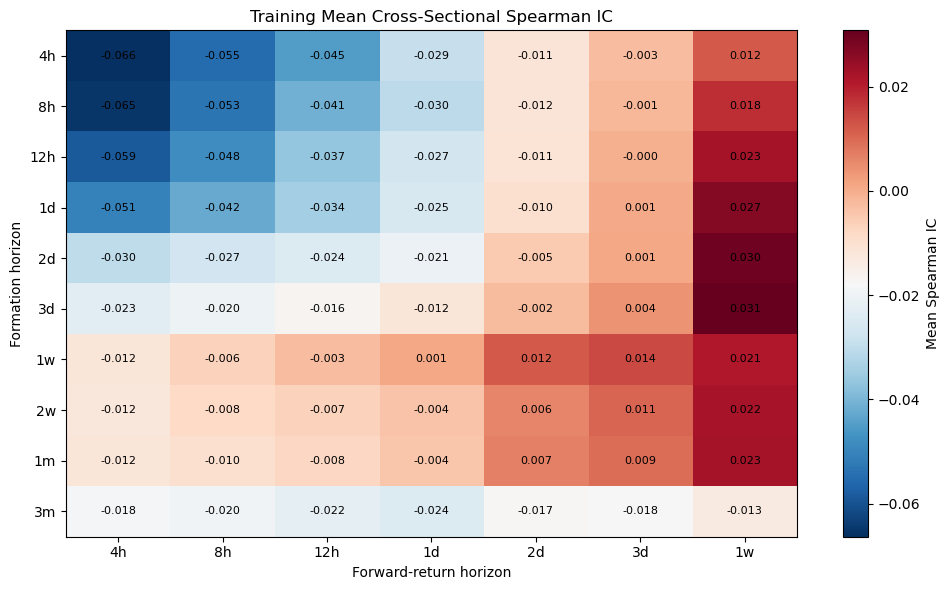

Stable same-sign regions:


,region_rank,sign,n_cells,avg_abs_ic,representative_formation,representative_forward,representative_ic
0,1,negative,51,0.02266,4h,4h,-0.06633
1,2,positive,19,0.01433,3d,1w,0.03082


Selected training relationships:


,candidate,formation,forward,mean,hac_t,hac_p,pct_ic_correct_sign
0,Short-horizon reversal,4h,4h,-0.06633,-18.55915,0.0000,0.60043
1,Medium-horizon momentum,3d,1w,0.03082,2.76441,0.0057,0.55201


In [2]:
FORMATION_HORIZONS = {
    "4h": pd.Timedelta(hours=4),
    "8h": pd.Timedelta(hours=8),
    "12h": pd.Timedelta(hours=12),
    "1d": pd.Timedelta(days=1),
    "2d": pd.Timedelta(days=2),
    "3d": pd.Timedelta(days=3),
    "1w": pd.Timedelta(days=7),
    "2w": pd.Timedelta(days=14),
    "1m": pd.Timedelta(days=30),
    "3m": pd.Timedelta(days=90),
}

FORWARD_HORIZONS = {
    "4h": pd.Timedelta(hours=4),
    "8h": pd.Timedelta(hours=8),
    "12h": pd.Timedelta(hours=12),
    "1d": pd.Timedelta(days=1),
    "2d": pd.Timedelta(days=2),
    "3d": pd.Timedelta(days=3),
    "1w": pd.Timedelta(days=7),
}


def exact_formation_return(prices, delta):
    past = prices.reindex(prices.index - delta).copy()
    past.index = prices.index
    return prices / past - 1.0


def exact_forward_return(prices, delta):
    future = prices.reindex(prices.index + delta).copy()
    future.index = prices.index
    return future / prices - 1.0


def rowwise_spearman(a, b, min_assets=MIN_IC_ASSETS):
    valid = a.notna() & b.notna()
    n_assets = valid.sum(axis=1)

    a_rank = a.where(valid).rank(axis=1, method="average")
    b_rank = b.where(valid).rank(axis=1, method="average")
    a_centered = a_rank.sub(a_rank.mean(axis=1), axis=0)
    b_centered = b_rank.sub(b_rank.mean(axis=1), axis=0)

    numerator = (a_centered * b_centered).sum(axis=1, min_count=1)
    denominator = np.sqrt(
        (a_centered ** 2).sum(axis=1) * (b_centered ** 2).sum(axis=1)
    )
    ic = numerator / denominator
    ic = ic.where((n_assets >= min_assets) & (denominator > 0))
    return ic, n_assets


def hac_mean_summary(series, maxlags=HAC_LAGS):
    y = pd.Series(series).dropna().astype(float)
    X = np.ones((len(y), 1))
    model = sm.OLS(y.to_numpy(), X).fit(
        cov_type="HAC", cov_kwds={"maxlags": maxlags}
    )
    return {
        "n": len(y),
        "mean": float(y.mean()),
        "median": float(y.median()),
        "hac_se": float(model.bse[0]),
        "hac_t": float(model.tvalues[0]),
        "hac_p": float(model.pvalues[0]),
    }


formation_return_panels = {
    label: exact_formation_return(close_panel, delta)
    for label, delta in FORMATION_HORIZONS.items()
}
forward_return_panels = {
    label: exact_forward_return(close_panel, delta)
    for label, delta in FORWARD_HORIZONS.items()
}

training_months = sorted({month_start(t) for t in candidate_times})
records = []

for month in training_months:
    members = list(membership_by_month[month])
    month_times = candidate_times[[month_start(t) == month for t in candidate_times]]

    for formation_label in FORMATION_HORIZONS:
        signal_block = formation_return_panels[formation_label].loc[month_times, members]

        for forward_label in FORWARD_HORIZONS:
            future_block = forward_return_panels[forward_label].loc[month_times, members]
            ic, n_assets = rowwise_spearman(signal_block, future_block)
            records.append(
                pd.DataFrame(
                    {
                        "timestamp": month_times,
                        "formation_horizon": formation_label,
                        "forward_horizon": forward_label,
                        "ic": ic.to_numpy(),
                        "n_assets": n_assets.to_numpy(),
                    }
                )
            )

ic_panel = pd.concat(records, ignore_index=True)

cell_summary = (
    ic_panel.groupby(["formation_horizon", "forward_horizon"], observed=True)
    .agg(n_ic=("ic", "count"), mean_ic=("ic", "mean"), median_ic=("ic", "median"))
    .reset_index()
)

mean_ic_surface = (
    cell_summary.pivot(
        index="formation_horizon", columns="forward_horizon", values="mean_ic"
    )
    .reindex(index=list(FORMATION_HORIZONS), columns=list(FORWARD_HORIZONS))
)

# Four-neighbor same-sign regions; minimum three cells.
visited = np.zeros(mean_ic_surface.shape, dtype=bool)
regions = []
neighbor_offsets = [(-1, 0), (1, 0), (0, -1), (0, 1)]

for r in range(mean_ic_surface.shape[0]):
    for c in range(mean_ic_surface.shape[1]):
        if visited[r, c]:
            continue
        value = mean_ic_surface.iloc[r, c]
        if pd.isna(value) or value == 0:
            visited[r, c] = True
            continue

        sign = np.sign(value)
        queue = deque([(r, c)])
        visited[r, c] = True
        cells_in_region = []

        while queue:
            rr, cc = queue.popleft()
            cell_value = mean_ic_surface.iloc[rr, cc]
            cells_in_region.append((rr, cc, cell_value))

            for dr, dc in neighbor_offsets:
                nr, nc = rr + dr, cc + dc
                if not (0 <= nr < mean_ic_surface.shape[0] and 0 <= nc < mean_ic_surface.shape[1]):
                    continue
                if visited[nr, nc]:
                    continue
                neighbor = mean_ic_surface.iloc[nr, nc]
                if pd.notna(neighbor) and neighbor != 0 and np.sign(neighbor) == sign:
                    visited[nr, nc] = True
                    queue.append((nr, nc))

        if len(cells_in_region) >= 3:
            representative = max(cells_in_region, key=lambda x: abs(x[2]))
            regions.append(
                {
                    "sign": "positive" if sign > 0 else "negative",
                    "n_cells": len(cells_in_region),
                    "avg_abs_ic": np.mean([abs(x[2]) for x in cells_in_region]),
                    "representative_formation": mean_ic_surface.index[representative[0]],
                    "representative_forward": mean_ic_surface.columns[representative[1]],
                    "representative_ic": representative[2],
                }
            )

region_summary = (
    pd.DataFrame(regions)
    .sort_values("avg_abs_ic", ascending=False)
    .reset_index(drop=True)
)
region_summary.insert(0, "region_rank", np.arange(1, len(region_summary) + 1))

candidate_specs = {
    "Short-horizon reversal": ("4h", "4h"),
    "Medium-horizon momentum": ("3d", "1w"),
}

candidate_rows = []
for candidate, (formation, forward) in candidate_specs.items():
    series = ic_panel.loc[
        (ic_panel["formation_horizon"] == formation)
        & (ic_panel["forward_horizon"] == forward),
        "ic",
    ]
    stats = hac_mean_summary(series)
    sign_share = (series.dropna() < 0).mean() if stats["mean"] < 0 else (series.dropna() > 0).mean()
    candidate_rows.append(
        {
            "candidate": candidate,
            "formation": formation,
            "forward": forward,
            **stats,
            "pct_ic_correct_sign": sign_share,
        }
    )

selected_candidates = pd.DataFrame(candidate_rows)

# Frozen-result guards: these are the canonical training means from the original research.
assert mean_ic_surface.shape == (10, 7)
assert len(region_summary) == 2
assert np.isclose(mean_ic_surface.loc["4h", "4h"], -0.066333, atol=5e-6)
assert np.isclose(mean_ic_surface.loc["3d", "1w"], 0.030821, atol=5e-6)

fig, ax = plt.subplots(figsize=(10, 6))
image = ax.imshow(mean_ic_surface.to_numpy(dtype=float), aspect="auto", cmap="RdBu_r")
ax.set_xticks(range(len(mean_ic_surface.columns)), mean_ic_surface.columns)
ax.set_yticks(range(len(mean_ic_surface.index)), mean_ic_surface.index)
ax.set_xlabel("Forward-return horizon")
ax.set_ylabel("Formation horizon")
ax.set_title("Training Mean Cross-Sectional Spearman IC")
for i in range(mean_ic_surface.shape[0]):
    for j in range(mean_ic_surface.shape[1]):
        value = mean_ic_surface.iloc[i, j]
        if pd.notna(value):
            ax.text(j, i, f"{value:.3f}", ha="center", va="center", fontsize=8)
fig.colorbar(image, ax=ax, label="Mean Spearman IC")
fig.tight_layout()
plt.show()

print("Stable same-sign regions:")
display(region_summary.round(5))
print("Selected training relationships:")
display(
    selected_candidates[
        ["candidate", "formation", "forward", "mean", "hac_t", "hac_p", "pct_ic_correct_sign"]
    ].round(5)
)


### Horizon-research result

Two broad same-sign regions emerge. The strongest negative region is represented by **4h formation → 4h forward reversal**; the positive region is represented by **3d formation → 1w forward momentum**. These are treated as representative relationships from broad regions, not as permission to optimize a portfolio directly on the highest-IC cell.

The next question is **when** those relationships earn their predictive content after the signal is observed.


## 2. Signal decay

For the two fixed relationships above, the following week is decomposed into **42 non-overlapping future 4-hour buckets**. The primary interpretation is based on three broad timing regions fixed before examining the decay results:

- immediate: 0–1 day;
- intermediate: 1–3 days;
- later: 3–7 days.

No individual bucket is promoted simply because it has the largest IC.


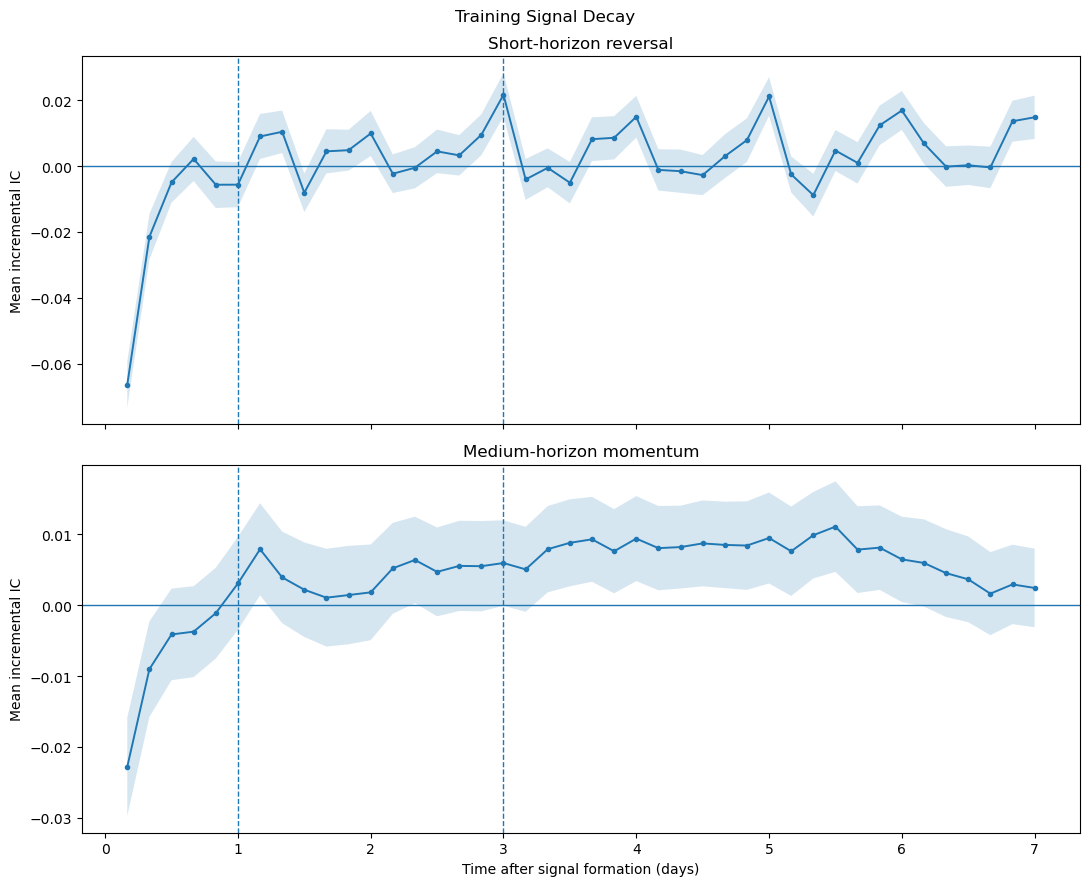

Predefined timing-region summary:


,candidate,timing_region,avg_incremental_mean_ic,pct_buckets_negative,pct_buckets_positive
0,Short-horizon reversal,Immediate (0–1d),-0.01698,0.83333,0.16667
1,Short-horizon reversal,Intermediate (1–3d),0.00554,0.25000,0.75000
2,Short-horizon reversal,Later (3–7d),0.00446,0.41667,0.58333
3,Medium-horizon momentum,Immediate (0–1d),-0.00630,0.83333,0.16667
4,Medium-horizon momentum,Intermediate (1–3d),0.00427,0.00000,1.00000
5,Medium-horizon momentum,Later (3–7d),0.00712,0.00000,1.00000


Maximum cumulative reproduction difference: 1.734723475976807e-18


In [3]:
N_DECAY_BUCKETS = 42
TIMING_REGIONS = {
    "Immediate (0–1d)": range(1, 7),
    "Intermediate (1–3d)": range(7, 19),
    "Later (3–7d)": range(19, 43),
}

formation_for_candidate = {
    "Short-horizon reversal": formation_return_panels["4h"],
    "Medium-horizon momentum": formation_return_panels["3d"],
}

incremental_returns = {}
for bucket in range(1, N_DECAY_BUCKETS + 1):
    start_delta = (bucket - 1) * BAR_SIZE
    end_delta = bucket * BAR_SIZE
    start_prices = close_panel.reindex(close_panel.index + start_delta).copy()
    end_prices = close_panel.reindex(close_panel.index + end_delta).copy()
    start_prices.index = close_panel.index
    end_prices.index = close_panel.index
    incremental_returns[bucket] = end_prices / start_prices - 1.0

decay_records = []
for month in training_months:
    members = list(membership_by_month[month])
    month_times = candidate_times[[month_start(t) == month for t in candidate_times]]

    for candidate, signal_panel in formation_for_candidate.items():
        signal_block = signal_panel.loc[month_times, members]
        for bucket in range(1, N_DECAY_BUCKETS + 1):
            future_block = incremental_returns[bucket].loc[month_times, members]
            ic, _ = rowwise_spearman(signal_block, future_block)
            decay_records.append(
                pd.DataFrame(
                    {
                        "timestamp": month_times,
                        "candidate": candidate,
                        "bucket": bucket,
                        "bucket_end_hours": bucket * 4,
                        "ic": ic.to_numpy(),
                    }
                )
            )

decay_ic_panel = pd.concat(decay_records, ignore_index=True)

bucket_rows = []
for candidate in candidate_specs:
    for bucket in range(1, N_DECAY_BUCKETS + 1):
        x = decay_ic_panel.loc[
            (decay_ic_panel["candidate"] == candidate)
            & (decay_ic_panel["bucket"] == bucket),
            "ic",
        ].dropna()
        stats = hac_mean_summary(x)
        bucket_rows.append(
            {
                "candidate": candidate,
                "bucket": bucket,
                "bucket_start_hours": (bucket - 1) * 4,
                "bucket_end_hours": bucket * 4,
                "mean_ic": stats["mean"],
                "hac_se": stats["hac_se"],
                "ci95_low": stats["mean"] - 1.96 * stats["hac_se"],
                "ci95_high": stats["mean"] + 1.96 * stats["hac_se"],
            }
        )

bucket_summary = pd.DataFrame(bucket_rows)

timing_rows = []
for candidate in candidate_specs:
    candidate_buckets = bucket_summary.loc[bucket_summary["candidate"] == candidate]
    for region_name, buckets in TIMING_REGIONS.items():
        region = candidate_buckets.loc[candidate_buckets["bucket"].isin(list(buckets))]
        timing_rows.append(
            {
                "candidate": candidate,
                "timing_region": region_name,
                "avg_incremental_mean_ic": region["mean_ic"].mean(),
                "pct_buckets_negative": (region["mean_ic"] < 0).mean(),
                "pct_buckets_positive": (region["mean_ic"] > 0).mean(),
            }
        )

timing_summary = pd.DataFrame(timing_rows)

# Reproduce the seven cumulative Step-3 candidate cells directly from the same panels.
crosscheck_rows = []
for candidate, formation_label in {
    "Short-horizon reversal": "4h",
    "Medium-horizon momentum": "3d",
}.items():
    for forward_label in FORWARD_HORIZONS:
        expected = mean_ic_surface.loc[formation_label, forward_label]
        panel_rows = []
        for month in training_months:
            members = list(membership_by_month[month])
            month_times = candidate_times[[month_start(t) == month for t in candidate_times]]
            ic, _ = rowwise_spearman(
                formation_return_panels[formation_label].loc[month_times, members],
                forward_return_panels[forward_label].loc[month_times, members],
            )
            panel_rows.append(ic)
        recomputed = pd.concat(panel_rows).mean()
        crosscheck_rows.append(
            {
                "candidate": candidate,
                "forward_horizon": forward_label,
                "recomputed_mean_ic": recomputed,
                "horizon_surface_mean_ic": expected,
                "difference": recomputed - expected,
            }
        )

cumulative_crosscheck = pd.DataFrame(crosscheck_rows)
assert cumulative_crosscheck["difference"].abs().max() < 1e-10

fig, axes = plt.subplots(2, 1, figsize=(11, 9), sharex=True)
for ax, candidate in zip(axes, candidate_specs):
    plot_data = bucket_summary.loc[bucket_summary["candidate"] == candidate]
    x_days = plot_data["bucket_end_hours"] / 24
    ax.plot(x_days, plot_data["mean_ic"], marker="o", markersize=3, linewidth=1.4)
    ax.fill_between(x_days, plot_data["ci95_low"], plot_data["ci95_high"], alpha=0.18)
    ax.axhline(0, linewidth=1)
    ax.axvline(1, linestyle="--", linewidth=1)
    ax.axvline(3, linestyle="--", linewidth=1)
    ax.set_ylabel("Mean incremental IC")
    ax.set_title(candidate)
axes[-1].set_xlabel("Time after signal formation (days)")
fig.suptitle("Training Signal Decay")
fig.tight_layout()
plt.show()

print("Predefined timing-region summary:")
display(timing_summary.round(5))
print("Maximum cumulative reproduction difference:", cumulative_crosscheck["difference"].abs().max())


### Decay result

The **4h reversal** relationship is strongly front-loaded: the immediate region is mostly negative and the effect largely dissipates thereafter. The **3d momentum** relationship is different: the first day is weak/negative, while the intermediate and later regions are consistently positive.

This timing evidence motivates carrying both an immediate momentum signal and a **one-day-delayed vintage** of that same signal into implementation research. The delay is a timing refinement, not a new formation rule.


## 3. Trading activity as a conditioning variable

The activity study asks whether abnormal trading activity changes the two fixed price relationships. It does **not** search activity thresholds or alternative lookbacks.

For each asset, quote volume is log-transformed and standardized relative to the **prior 30 calendar days (180 nominal 4h slots)**. The current observation is excluded from its own baseline. Missing activity observations are omitted inside the fixed window; the window is not extended farther backward. Shortened candles are unavailable for activity measurement.

- **Primary proxy:** quote volume
- **Confirmation proxy:** number of trades
- **4h reversal activity feature:** current abnormal activity
- **3d momentum activity feature:** mean abnormal activity over the exact 18-bar formation window, requiring all 18 observations

At each timestamp the future-return rank is regressed cross-sectionally on price rank, activity rank, and their interaction. The time series of interaction coefficients is then summarized with HAC(42) inference.


In [4]:
ACTIVITY_LOOKBACK_BARS = 180


def prior_rolling_zscore(panel, window=ACTIVITY_LOOKBACK_BARS):
    prior = panel.shift(1)
    rolling_mean = prior.rolling(window=window, min_periods=2).mean()
    rolling_std = prior.rolling(window=window, min_periods=2).std(ddof=1)
    z = (panel - rolling_mean) / rolling_std
    return z.where(rolling_std > 0)


log_quote_volume = np.log(quote_volume)
log_num_trades = np.log1p(num_trades)
quote_activity_z = prior_rolling_zscore(log_quote_volume)
trade_activity_z = prior_rolling_zscore(log_num_trades)

quote_activity_features = {
    "Short-horizon reversal": quote_activity_z,
    "Medium-horizon momentum": quote_activity_z.rolling(window=18, min_periods=18).mean(),
}
trade_activity_features = {
    "Short-horizon reversal": trade_activity_z,
    "Medium-horizon momentum": trade_activity_z.rolling(window=18, min_periods=18).mean(),
}

price_signal_panels = {
    "Short-horizon reversal": formation_return_panels["4h"],
    "Medium-horizon momentum": formation_return_panels["3d"],
}
future_signal_panels = {
    "Short-horizon reversal": forward_return_panels["4h"],
    "Medium-horizon momentum": forward_return_panels["1w"],
}


def centered_rank(series):
    return series.rank(method="average", pct=True) - 0.5


def cross_sectional_interaction(price_signal, activity_signal, future_return, min_assets=20):
    data = pd.concat(
        [
            price_signal.rename("price"),
            activity_signal.rename("activity"),
            future_return.rename("future"),
        ],
        axis=1,
    ).dropna()

    if len(data) < min_assets:
        return {
            "n_assets": len(data),
            "price_ic": np.nan,
            "beta_interaction": np.nan,
        }

    P = centered_rank(data["price"])
    A = centered_rank(data["activity"])
    Y = centered_rank(data["future"])
    X = sm.add_constant(
        pd.DataFrame({"price": P, "activity": A, "interaction": P * A}, index=data.index),
        has_constant="add",
    )
    model = sm.OLS(Y, X).fit()
    return {
        "n_assets": len(data),
        "price_ic": float(P.corr(Y)),
        "beta_interaction": float(model.params["interaction"]),
    }


activity_proxy_panels = {
    "quote_volume": quote_activity_features,
    "num_trades": trade_activity_features,
}

interaction_records = []
for candidate in candidate_specs:
    for proxy in ["quote_volume", "num_trades"]:
        activity_panel = activity_proxy_panels[proxy][candidate]
        for t in candidate_times:
            members = list(membership_by_month[month_start(t)])
            result = cross_sectional_interaction(
                price_signal_panels[candidate].loc[t, members],
                activity_panel.loc[t, members],
                future_signal_panels[candidate].loc[t, members],
                min_assets=MIN_IC_ASSETS,
            )
            interaction_records.append(
                {"timestamp": t, "candidate": candidate, "proxy": proxy, **result}
            )

interaction_panel = pd.DataFrame(interaction_records)

summary_rows = []
for candidate in candidate_specs:
    for proxy in ["quote_volume", "num_trades"]:
        subset = interaction_panel.loc[
            (interaction_panel["candidate"] == candidate)
            & (interaction_panel["proxy"] == proxy)
        ]
        interaction_stats = hac_mean_summary(subset["beta_interaction"])
        price_stats = hac_mean_summary(subset["price_ic"])
        summary_rows.append(
            {
                "candidate": candidate,
                "proxy": proxy,
                "valid_timestamps": interaction_stats["n"],
                "same_sample_price_ic": price_stats["mean"],
                "interaction_mean": interaction_stats["mean"],
                "interaction_hac_t": interaction_stats["hac_t"],
                "interaction_hac_p": interaction_stats["hac_p"],
            }
        )

interaction_summary = pd.DataFrame(summary_rows)
interaction_panel["year"] = interaction_panel["timestamp"].dt.year
yearly_interaction = (
    interaction_panel.groupby(["candidate", "proxy", "year"], observed=True)["beta_interaction"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

expected_valid = {
    "Short-horizon reversal": 5981,
    "Medium-horizon momentum": 5845,
}
for candidate, expected_n in expected_valid.items():
    for proxy in ["quote_volume", "num_trades"]:
        actual = int(
            interaction_summary.loc[
                (interaction_summary["candidate"] == candidate)
                & (interaction_summary["proxy"] == proxy),
                "valid_timestamps",
            ].iloc[0]
        )
        assert actual == expected_n

# Frozen pooled interaction means from the canonical research.
quote_summary = interaction_summary.loc[interaction_summary["proxy"] == "quote_volume"].set_index("candidate")
trade_summary = interaction_summary.loc[interaction_summary["proxy"] == "num_trades"].set_index("candidate")
assert np.isclose(quote_summary.loc["Short-horizon reversal", "interaction_mean"], 0.059902, atol=5e-6)
assert np.isclose(quote_summary.loc["Medium-horizon momentum", "interaction_mean"], -0.081603, atol=5e-6)
assert np.isclose(trade_summary.loc["Short-horizon reversal", "interaction_mean"], 0.059403, atol=5e-6)
assert np.isclose(trade_summary.loc["Medium-horizon momentum", "interaction_mean"], -0.076415, atol=5e-6)

print("Pooled activity-conditioning evidence:")
display(interaction_summary.round(5))
print("Year-by-year interaction coefficients:")
display(yearly_interaction.round(5))


Pooled activity-conditioning evidence:


,candidate,proxy,valid_timestamps,same_sample_price_ic,interaction_mean,interaction_hac_t,interaction_hac_p
0,Short-horizon reversal,quote_volume,5981,-0.06620,0.05990,5.34317,0.00000
1,Short-horizon reversal,num_trades,5981,-0.06620,0.05940,5.34492,0.00000
2,Medium-horizon momentum,quote_volume,5845,0.02987,-0.08160,-2.37989,0.01732
3,Medium-horizon momentum,num_trades,5845,0.02987,-0.07642,-2.30488,0.02117


Year-by-year interaction coefficients:


,candidate,proxy,year,count,mean,median
0,Medium-horizon momentum,num_trades,2020,1596,0.06398,0.05569
1,Medium-horizon momentum,num_trades,2021,2100,-0.15748,-0.19639
2,Medium-horizon momentum,num_trades,2022,2149,-0.10146,-0.09688
3,Medium-horizon momentum,quote_volume,2020,1596,0.05710,0.07081
4,Medium-horizon momentum,quote_volume,2021,2100,-0.15181,-0.17401
5,Medium-horizon momentum,quote_volume,2022,2149,-0.11601,-0.11020
6,Short-horizon reversal,num_trades,2020,1647,0.07964,0.09806
7,Short-horizon reversal,num_trades,2021,2185,0.09481,0.08712
8,Short-horizon reversal,num_trades,2022,2149,0.00790,0.00038
9,Short-horizon reversal,quote_volume,2020,1647,0.07546,0.06914


### Activity result

For short-horizon reversal, higher abnormal activity **weakens the reversal relationship** in pooled training evidence. Quote volume and trade count agree closely, but the interaction is much weaker by 2022 than in 2020–2021. One activity-conditioned reversal refinement is therefore carried forward, with the instability retained as a caveat.

For 3d → 1w momentum, the pooled activity interaction is negative but **changes sign through time**. An activity-conditioned momentum signal is therefore **not** promoted.

No activity threshold, alternative activity horizon, or regression-fitted scaling is introduced.


## 4. Frozen candidate signal set

The training evidence is now converted into four explicit signal objects for the portfolio stage. This is a **specification freeze**, not a performance comparison.

Let `P_4h` and `P_3d` denote centered cross-sectional percentile ranks of the corresponding formation returns and `A_4h` the centered rank of current abnormal quote activity.

1. **Baseline reversal:** `REV = -P_4h`
2. **Activity-conditioned reversal:** `REVACT = -P_4h × (1 - A_4h)`
3. **Immediate momentum:** `MOM = P_3d`
4. **One-day-delayed momentum:** `MOMD_t = P_3d_(t-1d)`

For the delayed version, the signal **vintage from one day earlier** is used; the 3d return is not recomputed at the later timestamp. Missing activity makes `REVACT` unavailable rather than falling back to baseline reversal.


In [5]:
DELAY = pd.Timedelta(days=1)
MIN_ASSETS = 20

return_4h = formation_return_panels["4h"]
return_3d = formation_return_panels["3d"]
reversal_quote_activity = quote_activity_z

candidate_names = [
    "reversal_baseline",
    "reversal_activity",
    "momentum_immediate",
    "momentum_delayed_1d",
]

candidate_panels = {
    name: pd.DataFrame(np.nan, index=candidate_times, columns=research_symbols, dtype=float)
    for name in candidate_names
}
price_rank_4h_panel = pd.DataFrame(np.nan, index=candidate_times, columns=research_symbols, dtype=float)
price_rank_3d_panel = pd.DataFrame(np.nan, index=candidate_times, columns=research_symbols, dtype=float)

for t in candidate_times:
    members = list(membership_by_month[month_start(t)])

    price_4h = return_4h.loc[t, members].dropna()
    if len(price_4h) >= MIN_ASSETS:
        P4 = centered_rank(price_4h)
        price_rank_4h_panel.loc[t, P4.index] = P4.values
        candidate_panels["reversal_baseline"].loc[t, P4.index] = -P4.values

    reversal_joint = pd.concat(
        [
            return_4h.loc[t, members].rename("price"),
            reversal_quote_activity.loc[t, members].rename("activity"),
        ],
        axis=1,
    ).dropna()
    if len(reversal_joint) >= MIN_ASSETS:
        P4_joint = centered_rank(reversal_joint["price"])
        A4 = centered_rank(reversal_joint["activity"])
        REVACT = -P4_joint * (1.0 - A4)
        candidate_panels["reversal_activity"].loc[t, REVACT.index] = REVACT.values

    price_3d = return_3d.loc[t, members].dropna()
    if len(price_3d) >= MIN_ASSETS:
        P3 = centered_rank(price_3d)
        price_rank_3d_panel.loc[t, P3.index] = P3.values
        candidate_panels["momentum_immediate"].loc[t, P3.index] = P3.values

for t in candidate_times:
    source_t = t - DELAY
    if source_t not in price_rank_3d_panel.index:
        continue
    current_members = list(membership_by_month[month_start(t)])
    delayed = price_rank_3d_panel.loc[source_t, current_members].dropna()
    if len(delayed) >= MIN_ASSETS:
        candidate_panels["momentum_delayed_1d"].loc[t, delayed.index] = delayed.values

coverage_rows = []
for candidate, panel in candidate_panels.items():
    counts = panel.notna().sum(axis=1)
    usable = counts >= MIN_ASSETS
    coverage_rows.append(
        {
            "candidate": candidate,
            "total_decision_timestamps": len(panel),
            "usable_timestamps_ge20": int(usable.sum()),
            "first_usable_timestamp": panel.index[usable][0] if usable.any() else pd.NaT,
            "last_usable_timestamp": panel.index[usable][-1] if usable.any() else pd.NaT,
            "min_assets_when_usable": int(counts[usable].min()) if usable.any() else np.nan,
            "median_assets_when_usable": float(counts[usable].median()) if usable.any() else np.nan,
            "max_assets_when_usable": int(counts[usable].max()) if usable.any() else np.nan,
        }
    )
coverage = pd.DataFrame(coverage_rows)

candidate_definition = pd.DataFrame(
    [
        ["reversal_baseline", "reversal", "-P_4h", "immediate", "none"],
        ["reversal_activity", "reversal", "-P_4h * (1 - A_4h)", "immediate", "abnormal quote volume"],
        ["momentum_immediate", "momentum", "P_3d", "immediate", "none"],
        ["momentum_delayed_1d", "momentum", "P_3d from exactly t - 1d", "one-day delayed", "none"],
    ],
    columns=["candidate", "family", "definition", "timing", "activity"],
)

# Structural guards, not performance tests.
baseline_diff = (candidate_panels["reversal_baseline"] + price_rank_4h_panel).stack(future_stack=True).dropna()
momentum_diff = (candidate_panels["momentum_immediate"] - price_rank_3d_panel).stack(future_stack=True).dropna()
assert baseline_diff.abs().max() < 1e-12
assert momentum_diff.abs().max() < 1e-12

expected_usable = {
    "reversal_baseline": 5989,
    "reversal_activity": 5981,
    "momentum_immediate": 5989,
    "momentum_delayed_1d": 5935,
}
for candidate, expected in expected_usable.items():
    actual = int(coverage.loc[coverage["candidate"] == candidate, "usable_timestamps_ge20"].iloc[0])
    assert actual == expected

# Exact old-vintage check for delayed momentum.
delay_diffs = []
for t in candidate_times:
    source_t = t - DELAY
    if source_t not in price_rank_3d_panel.index:
        continue
    members = list(membership_by_month[month_start(t)])
    lhs = candidate_panels["momentum_delayed_1d"].loc[t, members]
    rhs = price_rank_3d_panel.loc[source_t, members]
    valid = lhs.notna() & rhs.notna()
    if valid.any():
        delay_diffs.extend((lhs[valid] - rhs[valid]).abs().tolist())
assert delay_diffs and max(delay_diffs) < 1e-12

print("Frozen candidate definitions:")
display(candidate_definition)
print("Structural coverage:")
display(coverage)
print("Candidate-construction assertions: PASS")


Frozen candidate definitions:


,candidate,family,definition,timing,activity
0,reversal_baseline,reversal,-P_4h,immediate,none
1,reversal_activity,reversal,-P_4h * (1 - A_4h),immediate,abnormal quote volume
2,momentum_immediate,momentum,P_3d,immediate,none
3,momentum_delayed_1d,momentum,P_3d from exactly t - 1d,one-day delayed,none


Structural coverage:


,candidate,total_decision_timestamps,usable_timestamps_ge20,first_usable_timestamp,last_usable_timestamp,min_assets_when_usable,median_assets_when_usable,max_assets_when_usable
0,reversal_baseline,5989,5989,2020-04-01 00:00:00+00:00,2022-12-25 00:00:00+00:00,24,25.0,25
1,reversal_activity,5989,5981,2020-04-01 00:00:00+00:00,2022-12-25 00:00:00+00:00,24,25.0,25
2,momentum_immediate,5989,5989,2020-04-01 00:00:00+00:00,2022-12-25 00:00:00+00:00,24,25.0,25
3,momentum_delayed_1d,5989,5935,2020-04-02 00:00:00+00:00,2022-12-25 00:00:00+00:00,20,25.0,25


Candidate-construction assertions: PASS


## 5. Signal-research conclusion

The training stage ends with **four frozen candidate signals** and no portfolio-performance comparison:

- immediate 4h reversal;
- activity-conditioned 4h reversal;
- immediate 3d momentum;
- one-day-delayed 3d momentum.

Several tempting extensions are deliberately **not** introduced: activity-conditioned momentum, delayed reversal, delayed momentum × activity, optimized activity thresholds, regression-fitted activity scaling, or a training-optimized ensemble.

The next notebook converts these signal objects into neutral portfolios, applies turnover and transaction costs, and then opens the frozen **2023–2024 validation period**. That stage is where the original research architecture will either survive or fail.
